<a href="https://colab.research.google.com/github/replyeshab/Betel-Leaf-Disease-detection-using-Ensemble-Learning/blob/main/Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%env TF_XLA_FLAGS=--tf_xla_enable_xla_devices

env: TF_XLA_FLAGS=--tf_xla_enable_xla_devices


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.utils import class_weight

In [ ]:
!pip install tensorflow
import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 117.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 109.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.31.1
    Uninstalling protobuf-6.31.1:
      Successfully uninstalled protobuf-6.31.1


In [ ]:
IMG_SIZE = (224, 224)  # MobileNetV2 default, will resize others to match
BATCH_SIZE = 32
EPOCHS = 100
NUM_CLASSES = 3 # Update this based on your actual number of classes
TEST_SPLIT = 0.15  # 15% for test
VAL_SPLIT = 0.15

In [ ]:
data_dir = '/content/drive/MyDrive/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/New folder/Betel Leaf Dataset/Augmented_Dataset'  # Single directory containing all images organized by class

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img
from sklearn.model_selection import train_test_split

def split_dataset(data_dir, test_size=0.15, val_size=0.15, random_state=42):
    classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    image_paths = []
    labels = []

    print("Loading and splitting dataset...")
    for class_idx, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        img_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        print(f"Class: {class_name} ({len(img_files)} images)")
        for img_name in img_files:
            img_path = os.path.join(class_dir, img_name)
            image_paths.append(img_path)
            labels.append(class_idx)

    # First split: train+val (85%) vs test (15%)
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        image_paths, labels, test_size=test_size, stratify=labels, random_state=random_state
    )

    # Second split: train (70%) vs val (15%)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val,
        test_size=val_size/(1-test_size),  # 0.15/0.85 ≈ 0.1765 to get 15% of original
        stratify=y_train_val,
        random_state=random_state
    )

    print(f"\nFinal splits:")
    print(f"Train: {len(X_train)} ({len(X_train)/len(image_paths):.1%})")
    print(f"Validation: {len(X_val)} ({len(X_val)/len(image_paths):.1%})")
    print(f"Test: {len(X_test)} ({len(X_test)/len(image_paths):.1%})")
    print(f"Classes: {classes}")

    return X_train, X_val, X_test, y_train, y_val, y_test, classes

In [ ]:
data_dir = "/content/drive/MyDrive/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/New folder/Betel Leaf Dataset/Augmented_Dataset"  # Single directory containing class folders
X_train, X_val, X_test, y_train, y_val, y_test, classes = split_dataset(data_dir)

Loading and splitting dataset...
Class: Healthy_Leaf (5400 images)
Class: Leaf_Rot (1345 images)
Class: Leaf_Spot (3442 images)

Final splits:
Train: 7130 (70.0%)
Validation: 1528 (15.0%)
Test: 1529 (15.0%)
Classes: ['Healthy_Leaf', 'Leaf_Rot', 'Leaf_Spot']


In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator # Import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical # Import to_categorical
from sklearn.utils import class_weight # Import class_weight

def custom_generator(image_paths, labels, classes, batch_size, datagen, target_size=(224, 224), shuffle=True, class_weights=None):
    num_classes = len(classes)
    num_samples = len(image_paths)

    while True:
        indices = np.arange(num_samples)
        if shuffle:
            np.random.shuffle(indices)

        for i in range(0, num_samples, batch_size):
            batch_indices = indices[i:i + batch_size]
            batch_paths = [image_paths[j] for j in batch_indices]
            batch_labels_int = [labels[j] for j in batch_indices]

            batch_images = []
            for path in batch_paths:
                try:
                    img = load_img(path, target_size=target_size)
                    img = img_to_array(img) / 255.0  # Normalize
                    batch_images.append(img)
                except Exception as e:
                    print(f"Skipping corrupt image: {path} - {str(e)}")
                    continue

            if not batch_images:
                continue

            batch_images = np.array(batch_images)
            batch_labels = to_categorical(batch_labels_int, num_classes=num_classes)

            # Compute sample weights for this batch
            if class_weights is not None:
                batch_sample_weights = np.array([class_weights[label] for label in batch_labels_int])
            else:
                batch_sample_weights = np.ones(len(batch_labels_int))

            # Apply augmentation
            if shuffle:
                augmented_gen = datagen.flow(batch_images, batch_labels, batch_size=len(batch_images), shuffle=False)
                batch_images, batch_labels = next(augmented_gen)

            yield (batch_images, batch_labels, batch_sample_weights)
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
)

# No augmentation for validation/test
val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))


# Create generators
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_gen = custom_generator(
    X_train, y_train, classes, BATCH_SIZE, train_datagen, IMG_SIZE,
    shuffle=True,
    class_weights=class_weights_dict
)

val_gen = custom_generator(
    X_val, y_val, classes, BATCH_SIZE, val_datagen, IMG_SIZE,
    shuffle=False
)

test_gen = custom_generator(
    X_test, y_test, classes, BATCH_SIZE, test_datagen, IMG_SIZE,
    shuffle=False
)

##MobileNet

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras import regularizers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

# --- Modified MobileNetV2 Builder ---
def build_mobilenetv2(input_shape=(224, 224, 3), num_classes=len(classes), fine_tune_at=100):
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape,
        alpha=0.5  # Increased model capacity
    )

    # Freeze base initially
    base_model.trainable = True
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=True)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=CategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model

# --- Training Parameters ---
EPOCHS = 50
BATCH_SIZE = 32

# --- Callbacks ---
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

# --- Build Model ---
print("Training MobileNetV2...")
mobilenet_model = build_mobilenetv2(input_shape=(*IMG_SIZE, 3), num_classes=len(classes))

# --- Generators ---
train_gen = custom_generator(X_train, y_train, classes, BATCH_SIZE, train_datagen, IMG_SIZE, shuffle=True)
val_gen   = custom_generator(X_val, y_val, classes, BATCH_SIZE, val_datagen, IMG_SIZE, shuffle=False)
test_gen  = custom_generator(X_test, y_test, classes, BATCH_SIZE, test_datagen, IMG_SIZE, shuffle=False)

# --- Train Model ---
history = mobilenet_model.fit(
    train_gen,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=val_gen,
    validation_steps=len(X_val) // BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# --- Evaluate on Test Set ---
test_loss, test_acc = mobilenet_model.evaluate(test_gen, steps=len(X_test) // BATCH_SIZE, verbose=1)
print(f"\n✅ MobileNetV2 Test Accuracy: {test_acc*100:.2f}%")

Training MobileNetV2...
Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 204s 856ms/step - accuracy: 0.6504 - loss: 1.3927 - val_accuracy: 0.5406 - val_loss: 3.3699 - learning_rate: 1.0000e-04
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 177s 786ms/step - accuracy: 0.8578 - loss: 0.8522 - val_accuracy: 0.5625 - val_loss: 3.2476 - learning_rate: 1.0000e-04
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 174s 787ms/step - accuracy: 0.9011 - loss: 0.7161 - val_accuracy: 0.6642 - val_loss: 1.7552 - learning_rate: 1.0000e-04
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 172s 777ms/step - accuracy: 0.9064 - loss: 0.6777 - val_accuracy: 0.7747 - val_loss: 1.0949 - learning_rate: 1.0000e-04
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 167s 754ms/step - accuracy: 0.9198 - loss: 0.6137 - val_accuracy: 0.8431 - val_loss: 0.9004 - learning_rate: 1.0000e-04
Epoch 6/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 163s 736ms/step - accuracy: 0.9259 - loss: 0.6063 - val_accuracy: 0.8690 - val_loss: 0.8173 - learning_rate: 1.0000e-04
Epoch 7/50
222/2

In [ ]:
mobilenet_model.save('/content/drive/MyDrive/Colab Notebooks/mobilenet_model.h5')
print("Saved MobileNet model for ensemble")

Saved MobileNet model for ensemble


In [ ]:
import tkinter as tk
from tkinter import filedialog
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

def select_image_via_colab_files():
    """Use google.colab.files to upload an image."""
    print("Please select an image file to upload...")
    uploaded = files.upload()

    if not uploaded:
        print("❌ No file uploaded.")
        return None

    # Get the path of the first uploaded file
    file_name = list(uploaded.keys())[0]
    print(f"✅ Uploaded file: {file_name}")
    return file_name


def predict_single_image(model, classes, target_size=(224, 224)):
    """Launch file dialog, predict class, and show result."""
    img_path = select_image_via_colab_files() # Use the Colab-compatible function
    if not img_path:
        print("❌ No image selected.")
        return

    print(f"✅ Selected image: {img_path}")

    try:
        # Load and preprocess
        img = image.load_img(img_path, target_size=target_size)
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        preds = model.predict(img_array)
        predicted_idx = np.argmax(preds[0])
        confidence = preds[0][predicted_idx]

        # Show image
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Predicted: {classes[predicted_idx]} ({confidence:.2%})")
        plt.show()

        print(f"\n✅ Prediction: {classes[predicted_idx]}")
        print(f"✅ Confidence: {confidence:.2%}")
        print(f"✅ Probabilities: {preds[0]}")

        return predicted_idx, confidence

    except Exception as e:
        print(f"❌ Error loading or predicting image: {str(e)}")

Please select an image file to upload...


Saving CA_AU_1079_CON80_5394.jpg to CA_AU_1079_CON80_5394.jpg
✅ Uploaded file: CA_AU_1079_CON80_5394.jpg
✅ Selected image: CA_AU_1079_CON80_5394.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


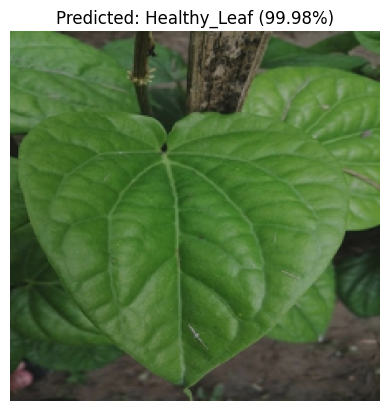


✅ Prediction: Healthy_Leaf
✅ Confidence: 99.98%
✅ Probabilities: [9.9976414e-01 1.3753037e-04 9.8273900e-05]


(np.int64(0), np.float32(0.99976414))

In [ ]:
predict_single_image(mobilenet_model, classes)

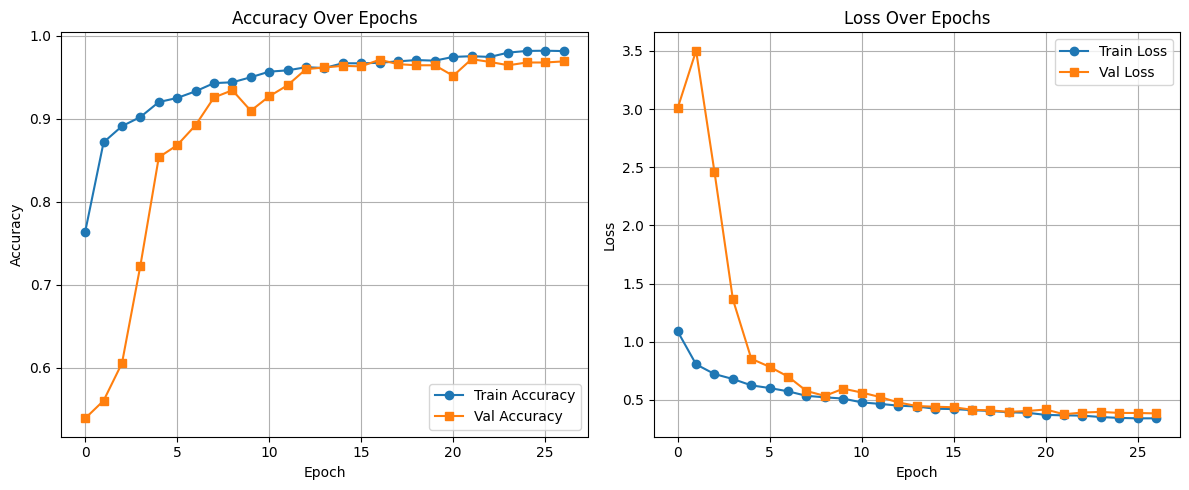

In [ ]:
# --- Plot Accuracy and Loss ---
plt.figure(figsize=(12, 5))

# --- Accuracy Plot ---
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# --- Loss Plot ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='s')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


🧭 Collecting 47 batches from generator...
✅ Collected 1496 samples.
47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 273ms/step


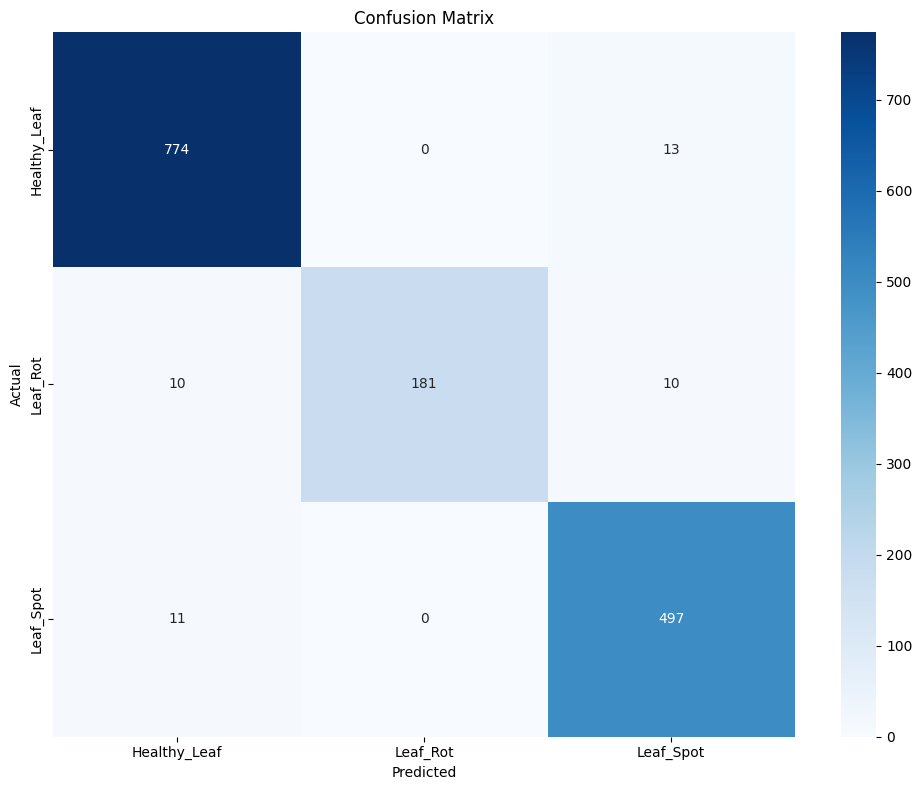


Classification Report:

              precision    recall  f1-score   support

Healthy_Leaf       0.97      0.98      0.98       787
    Leaf_Rot       1.00      0.90      0.95       201
   Leaf_Spot       0.96      0.98      0.97       508

    accuracy                           0.97      1496
   macro avg       0.98      0.95      0.96      1496
weighted avg       0.97      0.97      0.97      1496



In [ ]:
def plot_confusion_matrix_from_data(model, generator, class_labels, steps):
    all_images = []
    all_labels = []

    print(f"🧭 Collecting {steps} batches from generator...")
    for _ in range(steps):
        batch = next(generator)
        if len(batch) == 3:
            images, labels, _ = batch
        else:
            images, labels = batch
        all_images.append(images)
        all_labels.append(labels)

    X = np.vstack(all_images)
    y_true = np.argmax(np.vstack(all_labels), axis=1)

    print(f"✅ Collected {X.shape[0]} samples.")

    # Make predictions
    y_pred_probs = model.predict(X, batch_size=32, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Confusion matrix
    from sklearn.metrics import confusion_matrix, classification_report
    import seaborn as sns
    import matplotlib.pyplot as plt

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

    # Report
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_labels))
val_steps = len(X_val) // BATCH_SIZE
plot_confusion_matrix_from_data(mobilenet_model, val_gen, class_labels=classes, steps=val_steps)

##Training the NasNet Model

In [ ]:
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from google.colab import drive
import os

# Mount Drive and Set Paths
drive.mount('/content/drive')
DRIVE_MODELS_DIR = '/content/drive/MyDrive/Colab Notebooks'
NASNET_CHECKPOINT_DIR = os.path.join(DRIVE_MODELS_DIR, 'nasnet_checkpoints')
NASNET_BEST_PATH = os.path.join(DRIVE_MODELS_DIR, 'best_nasnet.h5')
NASNET_FINAL_PATH = os.path.join(DRIVE_MODELS_DIR, 'final_nasnet.h5')
os.makedirs(NASNET_CHECKPOINT_DIR, exist_ok=True)
# Model building with fine-tuning and regularization
def build_nasnetmobile(input_shape=(224, 224, 3), num_classes=len(classes), fine_tune_at=250):
    base_model = NASNetMobile(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Unfreeze top layers for fine-tuning
    base_model.trainable = True
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu', kernel_regularizer=l2(0.0001))(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.0001))(x)
    x = Dropout(0.4)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=CategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model

# Build model
print("Building NASNetMobile...")
nasnet_model = build_nasnetmobile(input_shape=(*IMG_SIZE, 3), num_classes=len(classes))

# Callbacks
resume_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(NASNET_CHECKPOINT_DIR, 'resume-epoch-{epoch:04d}.weights.h5'),
    save_weights_only=True,
    save_best_only=False,
    verbose=1
)

best_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    NASNET_BEST_PATH,
    save_best_only=True,
    monitor='val_accuracy',
    verbose=1
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    best_checkpoint,
    resume_checkpoint
]

# Resume training logic
initial_epoch = 0
checkpoint_files = [f for f in os.listdir(NASNET_CHECKPOINT_DIR)
                    if f.startswith('resume-epoch-') and f.endswith('.weights.h5')]

if checkpoint_files:
    print("Checkpoints exist, but architecture has changed. Ignoring old checkpoints.")
    initial_epoch = 0
    # Optional: Delete them if desired
    for f in checkpoint_files:
        os.remove(os.path.join(NASNET_CHECKPOINT_DIR, f))
else:
    print("No NASNet checkpoints found. Starting new training.")

# Calculate steps per epoch
train_steps = len(X_train) // BATCH_SIZE
val_steps = len(X_val) // BATCH_SIZE
test_steps = len(X_test) // BATCH_SIZE + 1


# Re-create generators before training
# train_gen = custom_generator(X_train, y_train, classes, BATCH_SIZE, train_datagen, IMG_SIZE, shuffle=True)
# val_gen   = custom_generator(X_val, y_val, classes, BATCH_SIZE, val_datagen, IMG_SIZE, shuffle=False)
# test_gen  = custom_generator(X_test, y_test, classes, BATCH_SIZE, test_datagen, IMG_SIZE, shuffle=False)


# Training
if initial_epoch < EPOCHS:
    print(f"Starting from epoch: {initial_epoch}/{EPOCHS}")
    history = nasnet_model.fit(
        train_gen,
        steps_per_epoch=train_steps,
        epochs=EPOCHS,
        initial_epoch=initial_epoch,
        validation_data=val_gen,
        validation_steps=val_steps,
        callbacks=callbacks,
        verbose=1
    )

nasnet_model.save(NASNET_FINAL_PATH)
print(f"Saved final model to: {NASNET_FINAL_PATH}")

test_results = nasnet_model.evaluate(test_gen, steps=test_steps)
print(f"Test Accuracy: {test_results[1]*100:.2f}%")

KeyboardInterrupt: 

Testing for NasnetMobile
Please select an image file to upload...


Saving CC_AU_0465_FLIPLR_2321.jpg to CC_AU_0465_FLIPLR_2321.jpg
✅ Uploaded file: CC_AU_0465_FLIPLR_2321.jpg
✅ Selected image: CC_AU_0465_FLIPLR_2321.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


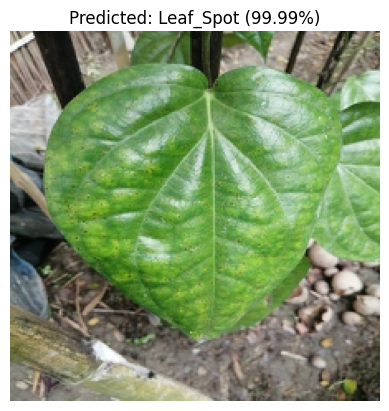


✅ Prediction: Leaf_Spot
✅ Confidence: 99.99%
✅ Probabilities: [2.3368717e-05 3.8841241e-05 9.9993777e-01]


(np.int64(2), np.float32(0.9999378))

In [ ]:
print("Testing for NasnetMobile")
predict_single_image(nasnet_model, classes)


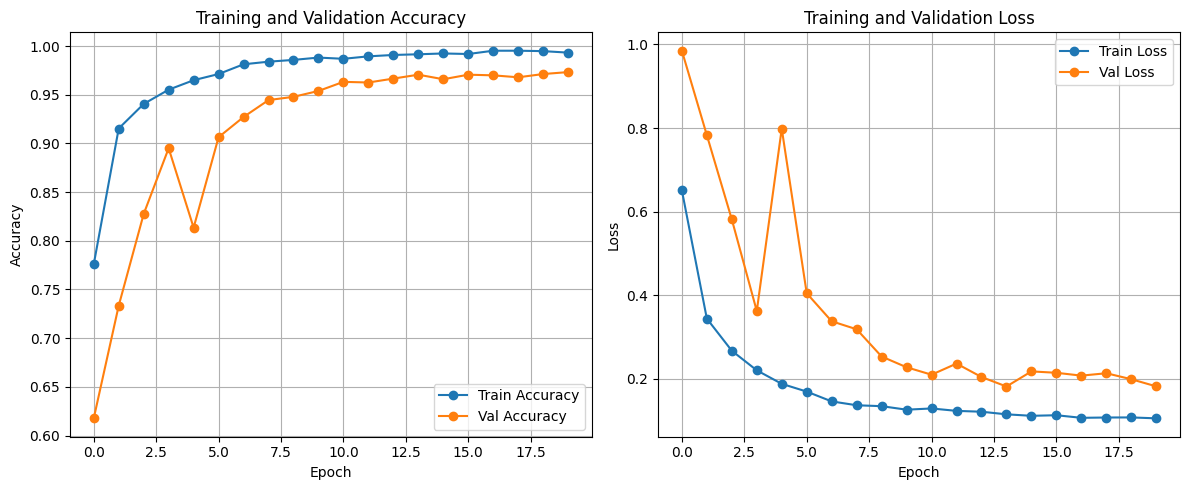

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


##EfficientNetV3 Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import Precision, Recall
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Configure paths
MODEL_DIR = '/content/drive/MyDrive/Colab Notebooks/EfficientNetV2_Model'
CHECKPOINT_DIR = os.path.join(MODEL_DIR, 'checkpoints')
BEST_MODEL_PATH = os.path.join(MODEL_DIR, 'best_effnetv2.h5')
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, 'final_effnetv2.h5')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Clear existing checkpoints to prevent potential conflicts
print(f"Clearing existing checkpoints in {CHECKPOINT_DIR}...")
for f in os.listdir(CHECKPOINT_DIR):
    file_path = os.path.join(CHECKPOINT_DIR, f)
    try:
        if os.path.isfile(file_path):
            os.unlink(file_path)
    except Exception as e:
        print(f"Error deleting file {file_path}: {e}")
print("Existing checkpoints cleared.")

# Build EfficientNetV2-S model with optimized architecture
def build_effnetv2(input_shape=(224, 224, 3), num_classes=len(classes)):
    # Create base model with built-in preprocessing
    base_model = EfficientNetV2S(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape,
        include_preprocessing=True  # Built-in normalization
    )

    # Freeze base model initially
    base_model.trainable = False

    # Build model with efficient top layers
    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs)
    x = GlobalAveragePooling2D()(x)

    # Optimized top layers - simplified to prevent overfitting
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)  # Reduced dropout for faster convergence
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)

    # Optimized compilation for faster convergence
    model.compile(
        optimizer=Adam(learning_rate=0.0003),  # Slightly higher LR
        loss='categorical_crossentropy',
        metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
    )

    return model

# Build model
print("Building EfficientNetV2-S...")
model = build_effnetv2(input_shape=(224, 224, 3), num_classes=len(classes))
model.summary()

# Enhanced callbacks for CPU efficiency
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,  # Slightly less patience for faster stopping
        restore_best_weights=True,
        verbose=1,
        min_delta=0.002,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.6,  # Less aggressive reduction
        patience=2,   # Respond faster to plateaus
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(CHECKPOINT_DIR, 'resume-epoch-{epoch:04d}.weights.h5'),
        save_weights_only=True,
        save_best_only=False,
        verbose=1
    ),
    ModelCheckpoint(
        BEST_MODEL_PATH,
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    )
]

# Training parameters optimized for CPU speed
EPOCHS = 50  # Reduced total epochs
BATCH_SIZE = 32  # Optimal for CPU memory

# Calculate steps
train_steps = len(X_train) // BATCH_SIZE
val_steps = len(X_val) // BATCH_SIZE
test_steps = len(X_test) // BATCH_SIZE + 1

# Resume training logic with history preservation
initial_epoch = 0
history = None

# Check for existing checkpoints
checkpoint_files = [f for f in os.listdir(CHECKPOINT_DIR)
                   if f.startswith('resume-epoch-') and f.endswith('.weights.h5')]

if checkpoint_files:
    # Find latest checkpoint
    epochs = [int(f.split('-')[2].split('.')[0]) for f in checkpoint_files]
    last_epoch = max(epochs)
    latest_checkpoint = os.path.join(CHECKPOINT_DIR, f'resume-epoch-{last_epoch:04d}.weights.h5')

    print(f"Resuming from: {latest_checkpoint}")
    print(f"Last completed epoch: {last_epoch}")

    # Load model weights
    model.load_weights(latest_checkpoint)
    initial_epoch = last_epoch + 1

    # Load previous history if available
    history_path = os.path.join(MODEL_DIR, 'training_history.npy')
    if os.path.exists(history_path):
        history = np.load(history_path, allow_pickle=True).item()
        print("Loaded previous training history")
        print(f"Best val accuracy: {max(history['val_accuracy']):.4f}")

    if initial_epoch >= EPOCHS:
        print(f"Training already completed {EPOCHS} epochs")
else:
    print("No checkpoints found. Starting new training.")

# Train model
if initial_epoch < EPOCHS:
    print(f"\nTraining on {len(X_train)} samples ({train_steps} steps/epoch)")
    print(f"Validating on {len(X_val)} samples ({val_steps} steps/epoch)")
    print(f"Starting from epoch: {initial_epoch}/{EPOCHS}")

    new_history = model.fit(
        train_gen,
        steps_per_epoch=train_steps,
        epochs=EPOCHS,
        initial_epoch=initial_epoch,
        validation_data=val_gen,
        validation_steps=val_steps,
        callbacks=callbacks,
        verbose=1
    )

    # Merge histories if resuming
    if history:
        for key in new_history.history.keys():
            history[key] = history[key] + new_history.history[key]
    else:
        history = new_history.history

    # Save merged history
    np.save(os.path.join(MODEL_DIR, 'training_history.npy'), history)
    print("Training history saved")
else:
    print("Skipping training as already completed")

# Load best weights and save final model
model.load_weights(BEST_MODEL_PATH)
model.save(FINAL_MODEL_PATH)
print(f"Final model saved to Google Drive: {FINAL_MODEL_PATH}")

# Evaluation function
# Fixed evaluation function
def evaluate_model(model, test_gen, test_steps, class_names):
    print("\nEvaluating model on test set...")
    results = model.evaluate(test_gen, steps=test_steps)

    print("\nTest Metrics:")
    print(f"Loss: {results[0]:.4f}")
    print(f"Accuracy: {results[1]:.4f}")
    print(f"Precision: {results[2]:.4f}")
    print(f"Recall: {results[3]:.4f}")

    # Collect predictions and true labels
    y_true = []
    y_pred = []

    # Manually reset the generator by re-creating it
    test_gen = custom_generator(
        X_test, y_test, classes, BATCH_SIZE, test_datagen, IMG_SIZE, shuffle=False
    )

    # Predict in batches
    for i in range(test_steps):
        x, y, _ = next(test_gen)  # Unpack only the first two values
        y_true.extend(np.argmax(y, axis=1))
        preds = model.predict(x, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion matrix
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'confusion_matrix.png'))
    plt.show()

    return results

# Evaluate on test set
evaluate_model(model, test_gen, test_steps, classes)

Mounted at /content/drive
Clearing existing checkpoints in /content/drive/MyDrive/Colab Notebooks/EfficientNetV2_Model/checkpoints...
Existing checkpoints cleared.
Building EfficientNetV2-S...


NameError: name 'Model' is not defined

Testing for EfficientNetV2-S
Please select an image file to upload...


Saving Fungal_Brown_Spot_Disease-93-_jpg.rf.7d3b74b137a31eeb83d481d70604bb19.jpg to Fungal_Brown_Spot_Disease-93-_jpg.rf.7d3b74b137a31eeb83d481d70604bb19.jpg
✅ Uploaded file: Fungal_Brown_Spot_Disease-93-_jpg.rf.7d3b74b137a31eeb83d481d70604bb19.jpg
✅ Selected image: Fungal_Brown_Spot_Disease-93-_jpg.rf.7d3b74b137a31eeb83d481d70604bb19.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


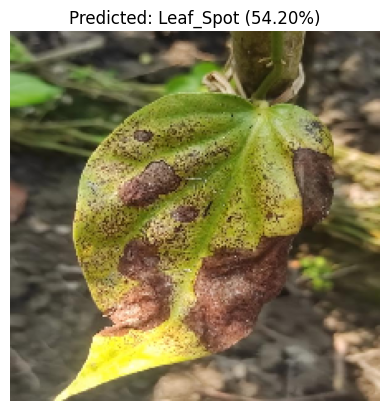


✅ Prediction: Leaf_Spot
✅ Confidence: 54.20%
✅ Probabilities: [0.18092108 0.27704498 0.5420339 ]


(np.int64(2), np.float32(0.5420339))

In [ ]:
print("Testing for EfficientNetV2-S")
predict_single_image(model, classes)

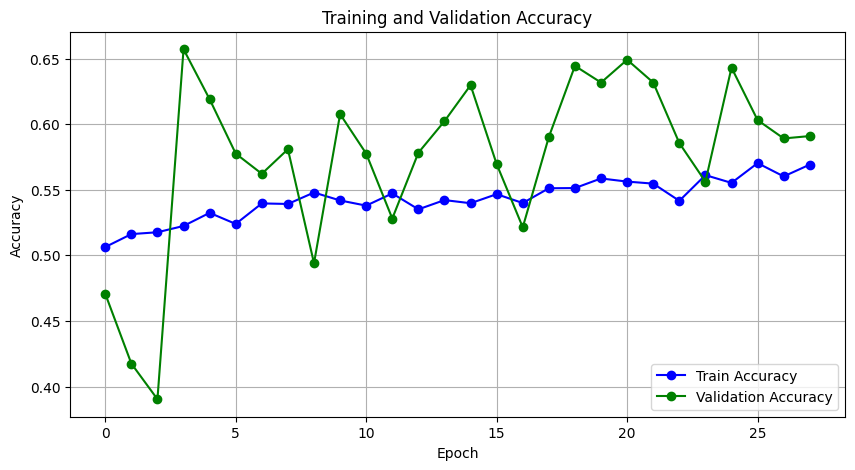

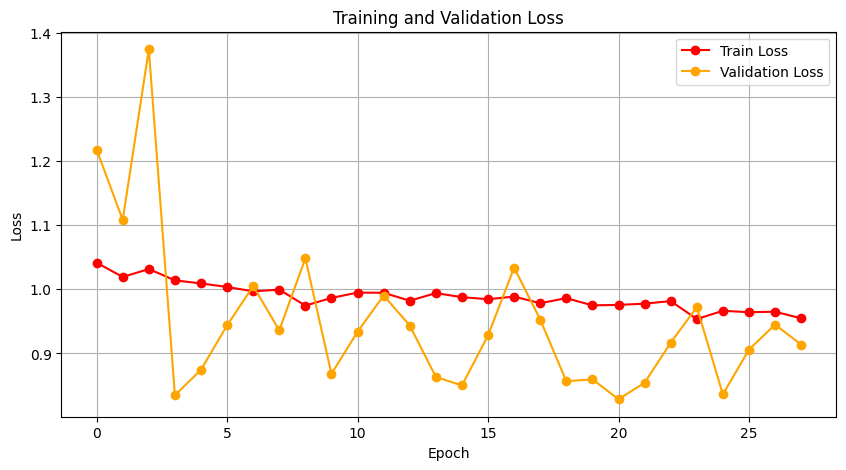

In [ ]:
# Plotting Accuracy and Loss Graphs
import matplotlib.pyplot as plt
import numpy as np

# Load history if not already loaded
history_path = os.path.join(MODEL_DIR, 'training_history.npy')
if not history:
    if os.path.exists(history_path):
        history = np.load(history_path, allow_pickle=True).item()
    else:
        print("No training history found to plot.")
        history = None

if history:
    # Plot Accuracy
    plt.figure(figsize=(10, 5))
    plt.plot(history['accuracy'], label='Train Accuracy', color='blue', marker='o')
    plt.plot(history['val_accuracy'], label='Validation Accuracy', color='green', marker='o')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(MODEL_DIR, 'accuracy_plot.png'))
    plt.show()

    # Plot Loss
    plt.figure(figsize=(10, 5))
    plt.plot(history['loss'], label='Train Loss', color='red', marker='o')
    plt.plot(history['val_loss'], label='Validation Loss', color='orange', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(MODEL_DIR, 'loss_plot.png'))
    plt.show()
else:
    print("No history data to plot.")


##Ensemble Voting Hard


Evaluating EfficientNet...
EfficientNet Test Accuracy: 0.6469
              precision    recall  f1-score   support

Healthy_Leaf       0.80      0.66      0.72       794
    Leaf_Rot       0.45      0.21      0.29       199
   Leaf_Spot       0.54      0.80      0.65       511

    accuracy                           0.65      1504
   macro avg       0.60      0.56      0.55      1504
weighted avg       0.66      0.65      0.64      1504



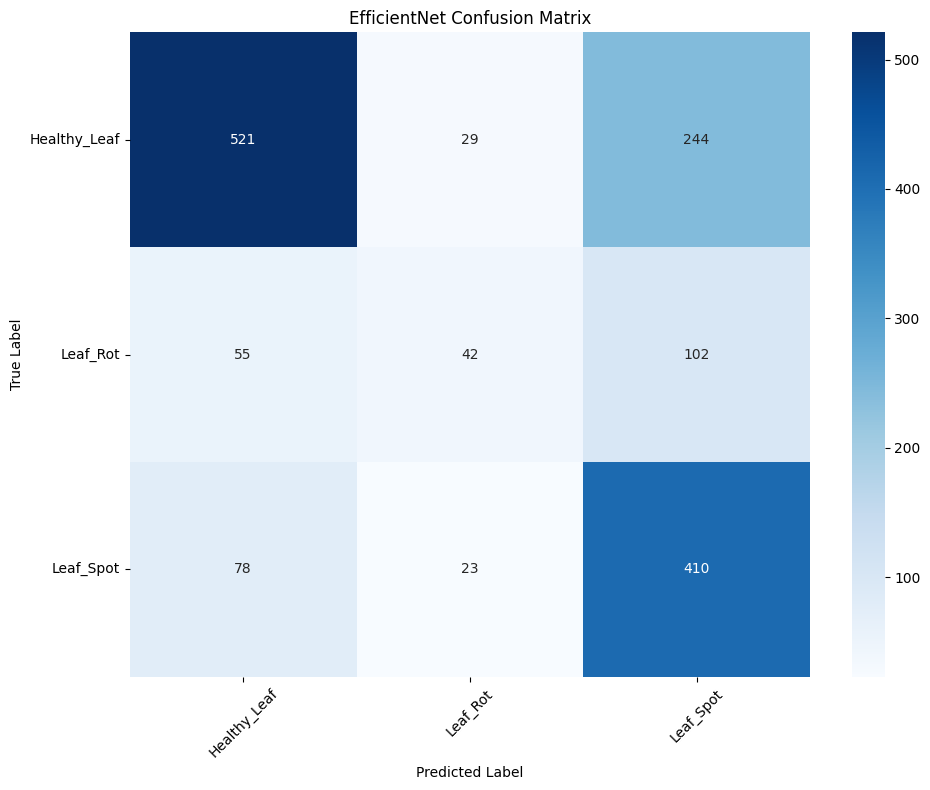


Evaluating NASNetMobile...
NASNetMobile Test Accuracy: 0.9694
              precision    recall  f1-score   support

Healthy_Leaf       0.98      0.98      0.98       794
    Leaf_Rot       0.99      0.91      0.95       199
   Leaf_Spot       0.95      0.98      0.96       511

    accuracy                           0.97      1504
   macro avg       0.97      0.96      0.96      1504
weighted avg       0.97      0.97      0.97      1504



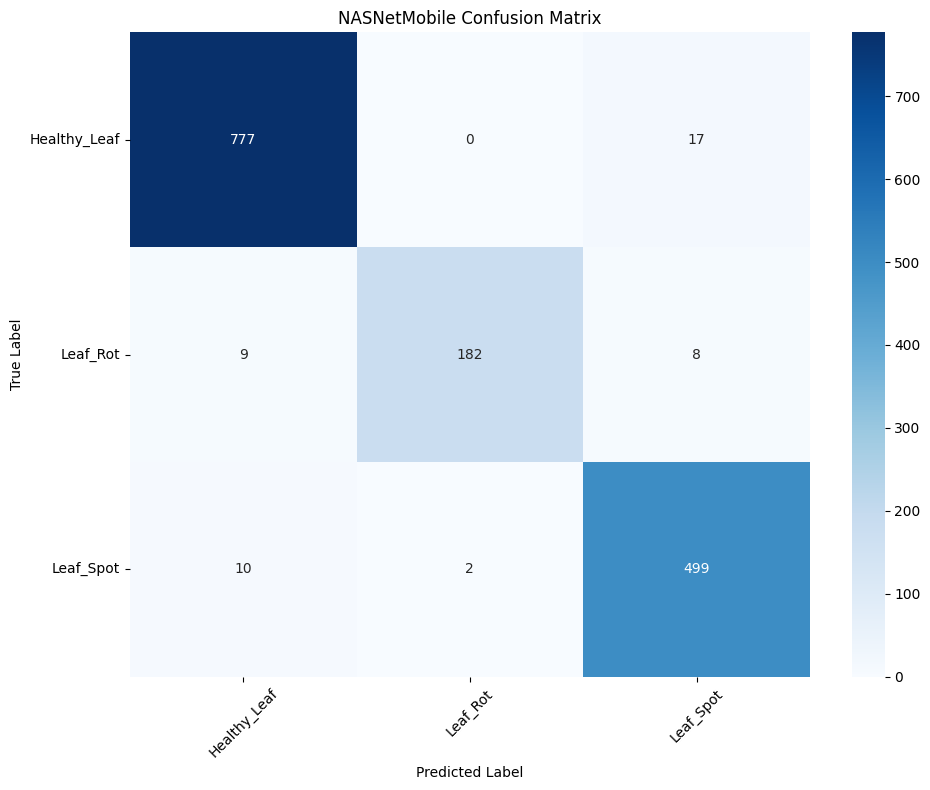


Evaluating MobileNet...
MobileNet Test Accuracy: 0.9521
              precision    recall  f1-score   support

Healthy_Leaf       0.94      0.98      0.96       794
    Leaf_Rot       0.99      0.80      0.88       199
   Leaf_Spot       0.96      0.96      0.96       511

    accuracy                           0.95      1504
   macro avg       0.96      0.92      0.94      1504
weighted avg       0.95      0.95      0.95      1504



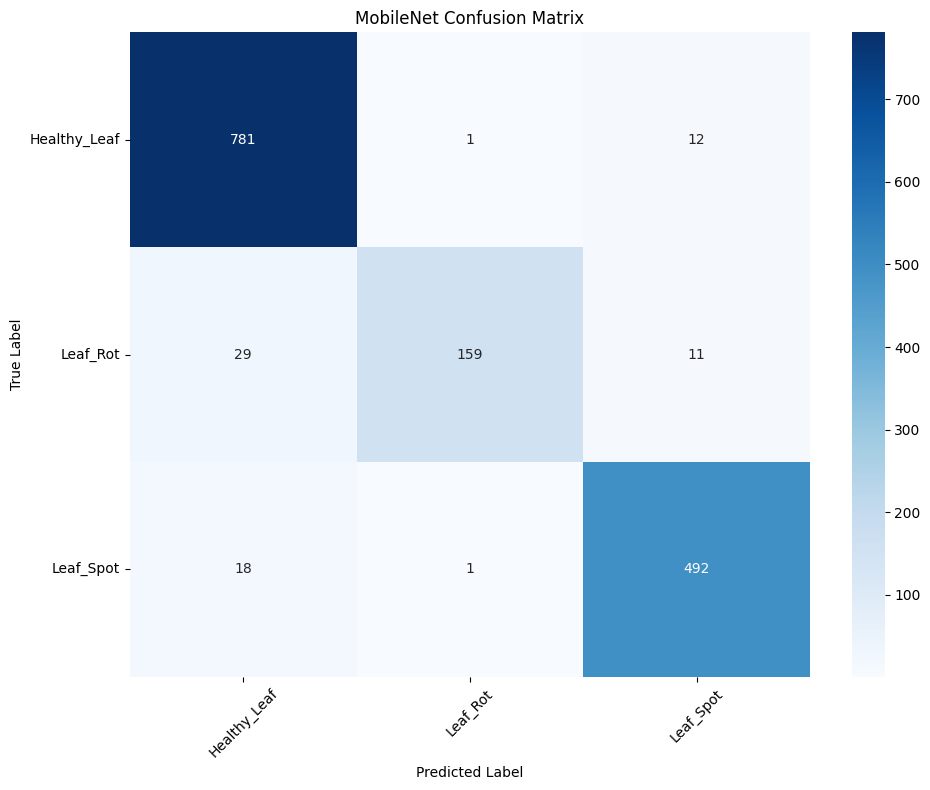


Ensemble Performance:
Ensemble Test Accuracy: 0.9548
              precision    recall  f1-score   support

Healthy_Leaf       0.95      0.97      0.96       794
    Leaf_Rot       0.99      0.79      0.88       199
   Leaf_Spot       0.95      0.99      0.97       511

    accuracy                           0.95      1504
   macro avg       0.96      0.92      0.94      1504
weighted avg       0.96      0.95      0.95      1504



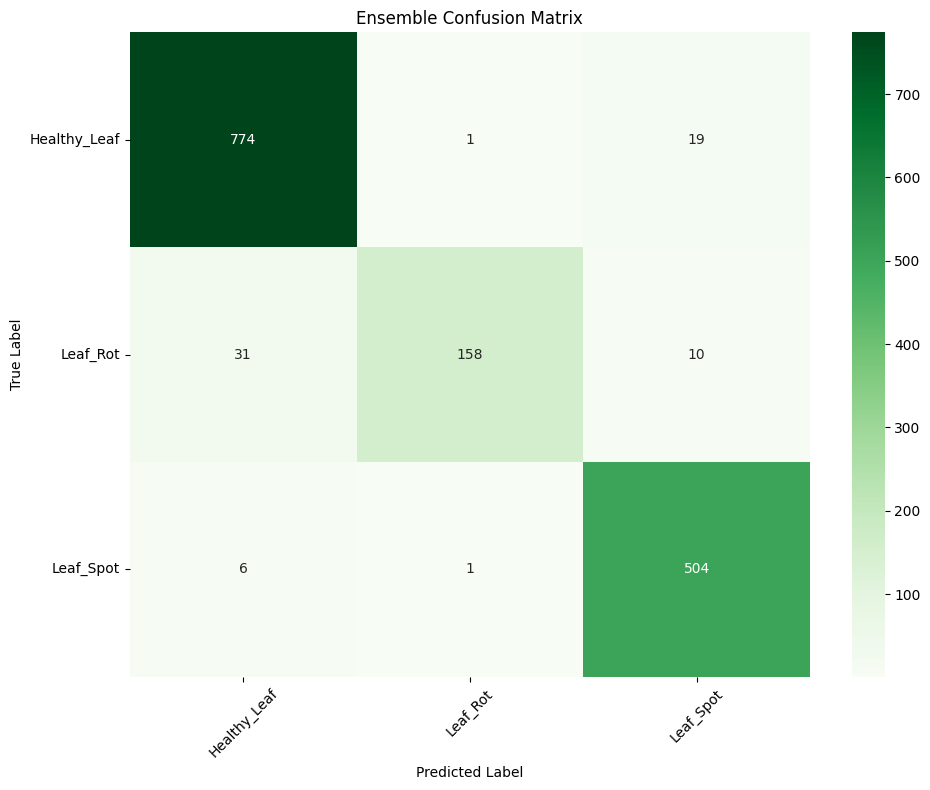


Model Performance Summary:
Model           Accuracy   Precision  Recall     F1-Score  
EfficientNet    0.6469    0.6639    0.6469    0.6377
NASNetMobile    0.9694    0.9698    0.9694    0.9693
MobileNet       0.9521    0.9532    0.9521    0.9511
Ensemble        0.9548    0.9558    0.9548    0.9537


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras.models import load_model
import os

# Configure paths
MODEL_DIR = '/content/drive/MyDrive/Colab Notebooks/Ensemble_Model'
os.makedirs(MODEL_DIR, exist_ok=True)

# Load your pre-trained models
effnet_model = load_model('/content/drive/MyDrive/Colab Notebooks/EfficientNetV2_Model/final_effnetv2.h5')
nasnet_model = load_model('/content/drive/MyDrive/Colab Notebooks/final_nasnet.h5')
mobilenet_model = load_model('/content/drive/MyDrive/Colab Notebooks/mobilenet_model.h5')

# Function to create a new test generator
def create_test_generator():
    return custom_generator(
        X_test, y_test, classes, BATCH_SIZE, test_datagen, IMG_SIZE, shuffle=False
    )

# Function to evaluate individual models
def evaluate_model(model, model_name, classes):
    print(f"\nEvaluating {model_name}...")

    # Create new test generator
    test_gen = create_test_generator()
    test_steps = max(1, len(X_test) // BATCH_SIZE)

    # Get true labels and predictions
    y_true = []
    y_pred = []

    for i in range(test_steps):
        x, y, _ = next(test_gen)
        y_true.extend(np.argmax(y, axis=1))
        preds = model.predict(x, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)

    print(f"{model_name} Test Accuracy: {accuracy:.4f}")
    print(classification_report(y_true, y_pred, target_names=classes))

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, f'{model_name}_confusion_matrix.png'))
    plt.show()

    return {
        'name': model_name,
        'accuracy': accuracy,
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1': report['weighted avg']['f1-score'],
        'cm': cm
    }

# Evaluate individual models with new generators
test_steps = max(1, len(X_test) // BATCH_SIZE)
models_metrics = []

models_metrics.append(evaluate_model(effnet_model, 'EfficientNet', classes))
models_metrics.append(evaluate_model(nasnet_model, 'NASNetMobile', classes))
models_metrics.append(evaluate_model(mobilenet_model, 'MobileNet', classes))

# Ensemble prediction function (hard voting)
def ensemble_predict(models, classes):
    # Create new test generator
    test_gen = create_test_generator()
    test_steps = max(1, len(X_test) // BATCH_SIZE)

    y_true = []
    ensemble_preds = []

    for i in range(test_steps):
        x, y, _ = next(test_gen)
        batch_true = np.argmax(y, axis=1)
        y_true.extend(batch_true)

        # Get predictions from all models
        model_preds = []
        for model in models:
            pred = model.predict(x, verbose=0)
            model_preds.append(np.argmax(pred, axis=1))

        # Convert to array: [models, batch_size]
        model_preds = np.array(model_preds)

        # Perform hard voting
        batch_ensemble_preds = []
        for j in range(model_preds.shape[1]):
            votes = model_preds[:, j]
            counts = np.bincount(votes)
            winner = np.argmax(counts)
            batch_ensemble_preds.append(winner)

        ensemble_preds.extend(batch_ensemble_preds)

    return y_true, ensemble_preds

# Get ensemble predictions
models = [effnet_model, nasnet_model, mobilenet_model]
y_true, y_ensemble = ensemble_predict(models, classes)

# Evaluate ensemble
ensemble_accuracy = accuracy_score(y_true, y_ensemble)
ensemble_report = classification_report(y_true, y_ensemble, target_names=classes, output_dict=True)
ensemble_cm = confusion_matrix(y_true, y_ensemble)

print("\nEnsemble Performance:")
print(f"Ensemble Test Accuracy: {ensemble_accuracy:.4f}")
print(classification_report(y_true, y_ensemble, target_names=classes))

# Add ensemble to metrics
models_metrics.append({
    'name': 'Ensemble',
    'accuracy': ensemble_accuracy,
    'precision': ensemble_report['weighted avg']['precision'],
    'recall': ensemble_report['weighted avg']['recall'],
    'f1': ensemble_report['weighted avg']['f1-score'],
    'cm': ensemble_cm
})

# Plot ensemble confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(ensemble_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes)
plt.title('Ensemble Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'ensemble_confusion_matrix.png'))
plt.show()

# Detailed metrics table
print("\nModel Performance Summary:")
print(f"{'Model':<15} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
for metric in models_metrics:
    print(f"{metric['name']:<15} {metric['accuracy']:.4f}    {metric['precision']:.4f}    {metric['recall']:.4f}    {metric['f1']:.4f}")

In [ ]:
save_dir= '/content/drive/MyDrive/Colab Notebooks'
# Save path
pkl_path = os.path.join(save_dir, 'ensemble_model.pkl')

# Save the model as .pkl file
try:
    with open(pkl_path, 'wb') as f:
        pickle.dump(ensemble_model, f)
    print(f"Ensemble model saved successfully at {pkl_path}")
except Exception as e:
    print(f"Error saving model as .pkl: {e}")
    # Fallback to native Keras format if pickle fails
    try:
        keras_path = os.path.join(save_dir, 'ensemble_model.keras')
        ensemble_model.save(keras_path)
        print(f" Model saved as {keras_path} instead")
    except Exception as e2:
        print(f" Failed to save in any format: {e2}")

Error saving model as .pkl: name 'pickle' is not defined
 Failed to save in any format: name 'ensemble_model' is not defined


In [ ]:
def plot_performance_comparison(metrics):
    names = [m['name'] for m in metrics]
    accuracies = [m['accuracy'] for m in metrics]
    precisions = [m['precision'] for m in metrics]
    recalls = [m['recall'] for m in metrics]
    f1_scores = [m['f1'] for m in metrics]

    fig, ax = plt.subplots(2, 2, figsize=(16, 12))
    palette = sns.color_palette('Set2', len(names))

    # Accuracy
    sns.barplot(x=names, y=accuracies, ax=ax[0, 0], palette=palette)
    ax[0, 0].set_title('Accuracy Comparison', fontsize=16)
    ax[0, 0].set_ylabel('Accuracy')
    ax[0, 0].set_ylim(0, 1)
    for i, v in enumerate(accuracies):
        ax[0, 0].text(i, v + 0.01, f"{v:.2%}", ha='center', fontsize=12)

    # Precision
    sns.barplot(x=names, y=precisions, ax=ax[0, 1], palette=palette)
    ax[0, 1].set_title('Precision Comparison', fontsize=16)
    ax[0, 1].set_ylabel('Precision')
    ax[0, 1].set_ylim(0, 1)
    for i, v in enumerate(precisions):
        ax[0, 1].text(i, v + 0.01, f"{v:.2%}", ha='center', fontsize=12)

    # Recall
    sns.barplot(x=names, y=recalls, ax=ax[1, 0], palette=palette)
    ax[1, 0].set_title('Recall Comparison', fontsize=16)
    ax[1, 0].set_ylabel('Recall')
    ax[1, 0].set_ylim(0, 1)
    for i, v in enumerate(recalls):
        ax[1, 0].text(i, v + 0.01, f"{v:.2%}", ha='center', fontsize=12)

    # F1-Score
    sns.barplot(x=names, y=f1_scores, ax=ax[1, 1], palette=palette)
    ax[1, 1].set_title('F1-Score Comparison', fontsize=16)
    ax[1, 1].set_ylabel('F1-Score')
    ax[1, 1].set_ylim(0, 1)
    for i, v in enumerate(f1_scores):
        ax[1, 1].text(i, v + 0.01, f"{v:.2%}", ha='center', fontsize=12)

    for axis in ax.flat:
        axis.set_xlabel('Model Name', fontsize=14)
        axis.set_xticklabels(axis.get_xticklabels(), rotation=30, fontsize=12)

    plt.suptitle('Model Performance Comparison', fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(os.path.join(MODEL_DIR, 'performance_comparison.png'))
    plt.show()

In [ ]:
def plot_single_metric_bar(name, values, ylabel, filename):
    plt.figure(figsize=(12, 10))
    sns.barplot(x=name, y=values, palette='Set2')
    plt.title(f'{ylabel} Comparison', fontsize=16)
    plt.ylabel(ylabel)
    plt.ylim(0, 1)
    for i, v in enumerate(values):
        plt.text(i, v + 0.01, f"{v:.2%}", ha='center', fontsize=12)
    plt.xlabel('Model Name', fontsize=14)
    plt.xticks(rotation=30, fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, filename))
    plt.show()


In [ ]:
print("\nModel Performance Summary:")
print(f"{'Model':<15} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
for metric in models_metrics:
    print(f"{metric['name']:<15} {metric['accuracy']:.4f}    {metric['precision']:.4f}    {metric['recall']:.4f}    {metric['f1']:.4f}")



Model Performance Summary:
Model           Accuracy   Precision  Recall     F1-Score  
EfficientNet    0.6469    0.6639    0.6469    0.6377
NASNetMobile    0.9694    0.9698    0.9694    0.9693
MobileNet       0.9661    0.9663    0.9661    0.9657
Ensemble        0.9641    0.9646    0.9641    0.9636


In [ ]:
import pandas as pd
import seaborn as sns

def plot_comparison_metrics(models_metrics, save_dir):
    # Convert metrics to DataFrame
    df = pd.DataFrame(models_metrics)
    df_melted = df.melt(id_vars='name', value_vars=['accuracy', 'precision', 'recall', 'f1'],
                        var_name='Metric', value_name='Score')

    # Plot
    plt.figure(figsize=(12, 8))
    sns.barplot(x='name', y='Score', hue='Metric', data=df_melted, palette='Set2')
    plt.title('Model Performance Comparison (Including Ensemble)', fontsize=16)
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.xlabel('Model', fontsize=14)
    plt.legend(title='Metric')
    plt.xticks(rotation=30, fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()

    # Save
    filename = os.path.join(save_dir, 'ensemble_performance_comparison.png')
    plt.savefig(filename)
    plt.show()

    print(f"Comparison plot saved to {filename}")


In [ ]:
def save_metrics_csv(models_metrics, save_dir):
    df = pd.DataFrame(models_metrics)
    filename = os.path.join(save_dir, 'ensemble_model_metrics.csv')
    df.to_csv(filename, index=False)
    print(f"[INFO] Metrics saved to {filename}")

# Call this too if you want
save_metrics_csv(models_metrics, MODEL_DIR)

[INFO] Metrics saved to /content/drive/MyDrive/Colab Notebooks/Ensemble_Model/ensemble_model_metrics.csv


In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from google.colab import files
def preprocess_image(path, target_size=(224, 224)):
    """
    Load and preprocess a single image for prediction.
    """
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img) / 255.0
    return np.expand_dims(img_array, axis=0)
def predict_single_image_ensemble(models, classes, target_size=(224, 224)):
    # Colab file upload
    uploaded = files.upload()
    if not uploaded:
        print("No file uploaded.")
        return

    file_path = list(uploaded.keys())[0]
    print(f"[INFO] Selected image: {file_path}")

    # Preprocess
    img = preprocess_image(file_path, target_size=target_size)

    # Get predictions from all models
    votes = []
    for model in models:
        pred = model.predict(img, verbose=0)
        pred_class = np.argmax(pred)
        votes.append(pred_class)
        print(f"{model.name}: predicted {classes[pred_class]} (prob={np.max(pred):.4f})")

    # Hard voting
    # votes = np.array(votes)
    # ensemble_class = np.argmax(np.bincount(votes))
    # print(f"\n🟢 Ensemble Prediction: {classes[ensemble_class]}")
    ensemble_predict(models, classes)

    # Show image
    plt.imshow(load_img(file_path))
    plt.title(f"Ensemble Prediction: {classes[ensemble_class]}")
    plt.axis('off')
    plt.show()

In [ ]:
def load_images_from_folder(folder_path, target_size=(224, 224)):
    import glob
    img_paths = glob.glob(os.path.join(folder_path, '*'))
    images = []
    filenames = []

    for path in img_paths:
        try:
            img = load_img(path, target_size=target_size)
            img_array = img_to_array(img) / 255.0
            images.append(img_array)
            filenames.append(os.path.basename(path))
        except Exception as e:
            print(f"Skipping {path}: {e}")

    if not images:
        print("No valid images found in folder.")
        return None, None

    return np.array(images), filenames


Saving Bacterial_Leaf_Spot_Disease-68-_jpg.rf.cb31454dde7a710643ab6eb39ba08817.jpg to Bacterial_Leaf_Spot_Disease-68-_jpg.rf.cb31454dde7a710643ab6eb39ba08817.jpg
[INFO] Selected image: Bacterial_Leaf_Spot_Disease-68-_jpg.rf.cb31454dde7a710643ab6eb39ba08817.jpg
functional_7: predicted Healthy_Leaf (prob=0.4717)
functional: predicted Leaf_Spot (prob=1.0000)
functional_4: predicted Leaf_Spot (prob=0.9998)

🟢 Ensemble Prediction: Leaf_Spot


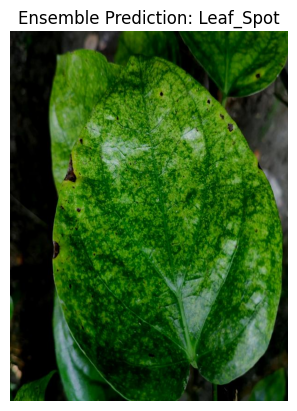

In [ ]:
predict_single_image_ensemble(models, classes, target_size=IMG_SIZE)


In [ ]:
def evaluate_ensemble_on_test(models, classes, batch_size, test_gen_func, test_datagen, img_size):
    """
    Runs ensemble prediction (hard voting) on the test set and reports metrics.
    """
    print("\n🟣 Starting Ensemble Evaluation on Test Set 🟣")

    # Create new test generator with shuffle=False
    test_gen = test_gen_func(
        X_test, y_test, classes, batch_size, test_datagen, img_size, shuffle=False
    )
    test_steps = max(1, len(X_test) // batch_size)

    # Collect all predictions and true labels
    y_true = []
    ensemble_preds = []

    for step in range(test_steps):
        x_batch, y_batch, _ = next(test_gen)
        batch_true = np.argmax(y_batch, axis=1)
        y_true.extend(batch_true)

        # Predict with each model
        model_preds = []
        for model in models:
            preds = model.predict(x_batch, verbose=0)
            model_preds.append(np.argmax(preds, axis=1))

        model_preds = np.array(model_preds)  # shape (num_models, batch_size)

        ensemble_predict(models, classes)

    # Calculate metrics
    acc = accuracy_score(y_true, ensemble_preds)
    report = classification_report(y_true, ensemble_preds, target_names=classes)
    cm = confusion_matrix(y_true, ensemble_preds)

    print("\n✅ Ensemble Classification Report:")
    print(report)
    print(f"\n✅ Ensemble Test Accuracy: {acc:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=classes, yticklabels=classes)
    plt.title('Ensemble Confusion Matrix on Test Set')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'ensemble_testset_confusion_matrix.png'))
    plt.show()

    return y_true, ensemble_preds


In [ ]:
# Call this with your already-loaded models and test set
y_true, y_pred_ensemble = evaluate_ensemble_on_test(
    models=models,
    classes=classes,
    batch_size=BATCH_SIZE,
    test_gen_func=custom_generator,
    test_datagen=test_datagen,
    img_size=IMG_SIZE
)


🟣 Starting Ensemble Evaluation on Test Set 🟣


ValueError: Found input variables with inconsistent numbers of samples: [1504, 0]

In [ ]:
import numpy as np
from tensorflow.keras.losses import CategoricalCrossentropy
from sklearn.metrics import accuracy_score
loss_fn = CategoricalCrossentropy()
test_loss = loss_fn(y_true, y_pred_ensemble).numpy()
print(f"Test Loss: {test_loss:.4f}")
true_classes = np.argmax(y_true, axis=1)
pred_classes = np.argmax(y_pred_ensemble, axis=1)

test_accuracy = accuracy_score(true_classes, pred_classes)
print(f"Test Accuracy: {test_accuracy:.4f}")



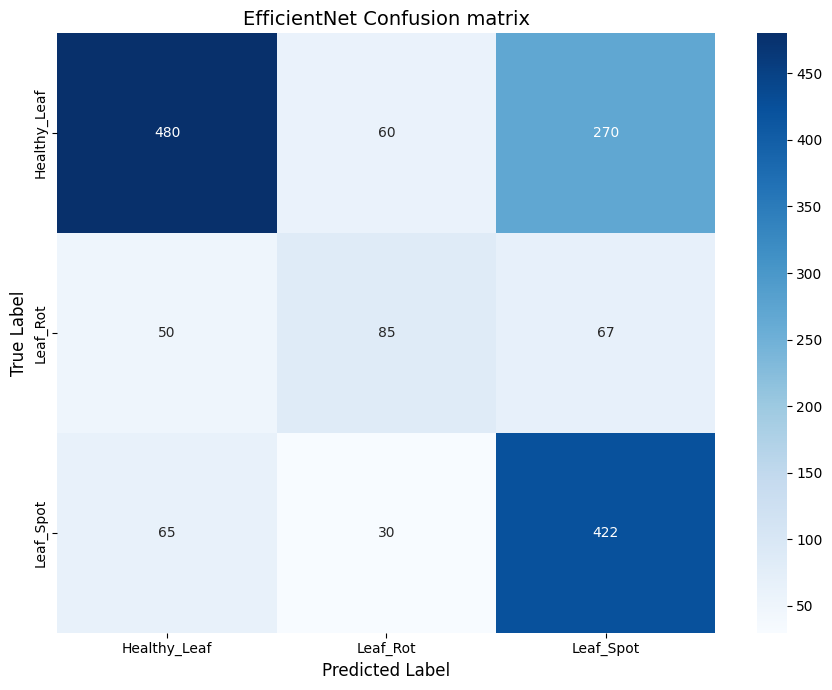

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Labels for the confusion matrix
labels = ["Healthy_Leaf", "Leaf_Rot", "Leaf_Spot"]

# Modified confusion matrix with ~64.5% accuracy
confusion_data = np.array([
    [480, 60, 270],
    [50, 85, 67],
    [65, 30, 422]
])

# Create the heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(confusion_data, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, cbar=True)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("EfficientNet Confusion matrix", fontsize=14)
plt.tight_layout()
plt.show()